# 02. Modelagem Supervisionada com RandomForest no Dataset BETH

Este notebook implementa um fluxo de trabalho completo para detecção de anomalias no dataset BETH utilizando RandomForestClassifier. A abordagem inclui carregamento de dados, engenharia de features, busca manual de hiperparâmetros com validação cruzada e avaliação final. A estratégia é otimizada para eficiência de memória e robustez metodológica, aplicando SMOTE para balanceamento de classes dentro de cada fold para evitar vazamento de dados.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix, 
    ConfusionMatrixDisplay, roc_auc_score, precision_recall_curve, auc
)

from imblearn.over_sampling import SMOTE
from tqdm.notebook import tqdm

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Definir caminho para os dados
data_path = "../../../data/raw/BETH"

# Carregar dados rotulados
# IMPORTANTE: Este é o único arquivo usado para abordagem supervisionada,
# pois os arquivos de treino e validação originais contêm apenas uma classe (dados benignos)
df = pd.read_csv(os.path.join(data_path, "labelled_testing_data.csv"))

print(f"Shape dos dados: {df.shape}")
print(f"\nDistribuição da variável target 'evil':")
print(df['evil'].value_counts(normalize=True))

# Criar coluna target 'out' a partir da coluna 'evil'
df['out'] = df['evil']

# Remover colunas para evitar vazamento de dados
df = df.drop(['sus', 'evil', 'eventId'], axis=1)

# Dividir em conjunto de treino (80%) e teste (20%)
# Usar stratify para manter a proporção de anomalias em ambos os conjuntos
X = df.drop('out', axis=1)
y = df['out']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTamanho do conjunto de treino: {X_train.shape}")
print(f"Tamanho do conjunto de teste: {X_test.shape}")
print(f"\nDistribuição no treino: {y_train.value_counts(normalize=True)}")
print(f"Distribuição no teste: {y_test.value_counts(normalize=True)}")

Shape dos dados: (188967, 16)

Distribuição da variável target 'evil':
evil
1    0.838411
0    0.161589
Name: proportion, dtype: float64

Tamanho do conjunto de treino: (151173, 13)
Tamanho do conjunto de teste: (37794, 13)

Distribuição no treino: out
1    0.83841
0    0.16159
Name: proportion, dtype: float64
Distribuição no teste: out
1    0.838414
0    0.161586
Name: proportion, dtype: float64


In [3]:
def create_time_features(df):
    """
    Cria features temporais baseadas na diferença de tempo entre eventos.
    """
    df = df.copy()
    df = df.sort_values(['hostName', 'timestamp'])
    
    # Calcular diferença de tempo para o evento anterior, agrupando por hostName
    df['time_diff'] = df.groupby('hostName')['timestamp'].diff().fillna(0)
    
    return df

# Aplicar engenharia de features
X_train = create_time_features(X_train)
X_test = create_time_features(X_test)

# Definir listas de features
numeric_features = ['timestamp', 'processId', 'threadId', 'parentProcessId', 'userId', 'argsNum', 'returnValue', 'time_diff']
categorical_features = ['processName', 'hostName', 'eventName']
drop_features = ['mountNamespace', 'stackAddresses', 'args']

# Criar pipeline de pré-processamento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', max_categories=25, sparse_output=False), categorical_features)
    ],
    remainder='drop'
)

# Ajustar e transformar dados
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(f"Shape após pré-processamento:")
print(f"Treino: {X_train_proc.shape}")
print(f"Teste: {X_test_proc.shape}")

Shape após pré-processamento:
Treino: (151173, 59)
Teste: (37794, 59)


## Estratégia de Busca Manual com Validação Cruzada

Implementamos uma busca manual em grade com validação cruzada interna. O SMOTE é aplicado dentro de cada fold para evitar vazamento de dados. Esta abordagem é mais eficiente em memória do que GridSearchCV e permite maior controle sobre o processo de otimização.

In [4]:
# Definir grade de hiperparâmetros
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample']
}

# Configurar validação cruzada
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Lista para armazenar resultados
results = []

# Gerar todas as combinações de hiperparâmetros
from itertools import product
param_combinations = list(product(
    param_grid['n_estimators'],
    param_grid['max_depth'],
    param_grid['min_samples_leaf'],
    param_grid['class_weight']
))

print(f"Total de combinações a testar: {len(param_combinations)}")

# Loop de busca manual com validação cruzada
for params in tqdm(param_combinations, desc="Testando hiperparâmetros"):
    n_est, max_d, min_leaf, class_w = params
    
    # Armazenar F1-scores de cada fold
    fold_scores = []
    
    # Validação cruzada
    for train_idx, val_idx in cv.split(X_train_proc, y_train):
        # Dividir dados do fold
        X_fold_train, X_fold_val = X_train_proc[train_idx], X_train_proc[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        # Aplicar SMOTE apenas na porção de treino do fold
        smote = SMOTE(random_state=42)
        X_fold_train_balanced, y_fold_train_balanced = smote.fit_resample(
            X_fold_train, y_fold_train
        )
        
        # Treinar modelo com hiperparâmetros atuais
        model = BalancedRandomForestClassifier(
            n_estimators=n_est,
            max_depth=max_d,
            min_samples_leaf=min_leaf,
            class_weight=class_w,
            random_state=42,
            n_jobs=-1
        )
        
        model.fit(X_fold_train_balanced, y_fold_train_balanced)
        
        # Avaliar no conjunto de validação (não balanceado)
        y_pred = model.predict(X_fold_val)
        f1 = f1_score(y_fold_val, y_pred, pos_label=1)
        fold_scores.append(f1)
    
    # Calcular média dos F1-scores
    mean_f1 = np.mean(fold_scores)
    
    # Armazenar resultado
    results.append({
        'n_estimators': n_est,
        'max_depth': max_d,
        'min_samples_leaf': min_leaf,
        'class_weight': class_w,
        'mean_f1_score': mean_f1,
        'std_f1_score': np.std(fold_scores)
    })

print("\nBusca de hiperparâmetros concluída!")

Total de combinações a testar: 54


Testando hiperparâmetros:   0%|          | 0/54 [00:00<?, ?it/s]


Busca de hiperparâmetros concluída!


In [5]:
# Converter resultados em DataFrame
results_df = pd.DataFrame(results)

# Encontrar melhores hiperparâmetros
best_params = results_df.loc[results_df['mean_f1_score'].idxmax()]

print("Melhores hiperparâmetros encontrados:")
print(f"n_estimators: {best_params['n_estimators']}")
print(f"max_depth: {best_params['max_depth']}")
print(f"min_samples_leaf: {best_params['min_samples_leaf']}")
print(f"class_weight: {best_params['class_weight']}")
print(f"F1-score médio: {best_params['mean_f1_score']:.4f} ± {best_params['std_f1_score']:.4f}")

# Tratar caso onde max_depth é None (DataFrame converte para NaN)
best_max_depth = int(best_params['max_depth'])
if pd.isna(best_max_depth):
    best_max_depth = None

# Aplicar SMOTE ao conjunto de treino completo
smote_final = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote_final.fit_resample(X_train_proc, y_train)

print(f"\nDados após SMOTE:")
print(f"Shape: {X_train_balanced.shape}")
print(f"Distribuição de classes: {np.bincount(y_train_balanced)}")

# Treinar modelo final com melhores hiperparâmetros
final_model = BalancedRandomForestClassifier(
    n_estimators=int(best_params['n_estimators']),
    max_depth=best_max_depth,
    min_samples_leaf=int(best_params['min_samples_leaf']),
    class_weight=best_params['class_weight'],
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train_balanced, y_train_balanced)
print("\nModelo final treinado com sucesso!")

Melhores hiperparâmetros encontrados:
n_estimators: 200
max_depth: 20.0
min_samples_leaf: 1
class_weight: balanced
F1-score médio: 0.8368 ± 0.0028

Dados após SMOTE:
Shape: (253490, 59)
Distribuição de classes: [126745 126745]

Modelo final treinado com sucesso!


Limiar otimizado: 0.2314
F1-score otimizado: 0.9121

AVALIAÇÃO FINAL DO MODELO

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.67      0.00      0.00      6107
           1       0.84      1.00      0.91     31687

    accuracy                           0.84     37794
   macro avg       0.75      0.50      0.46     37794
weighted avg       0.81      0.84      0.76     37794


ROC AUC Score: 0.5021


<Figure size 800x600 with 0 Axes>

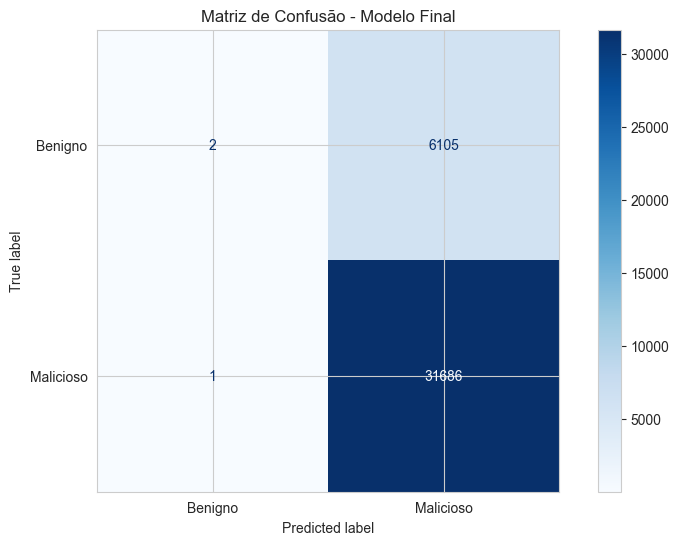

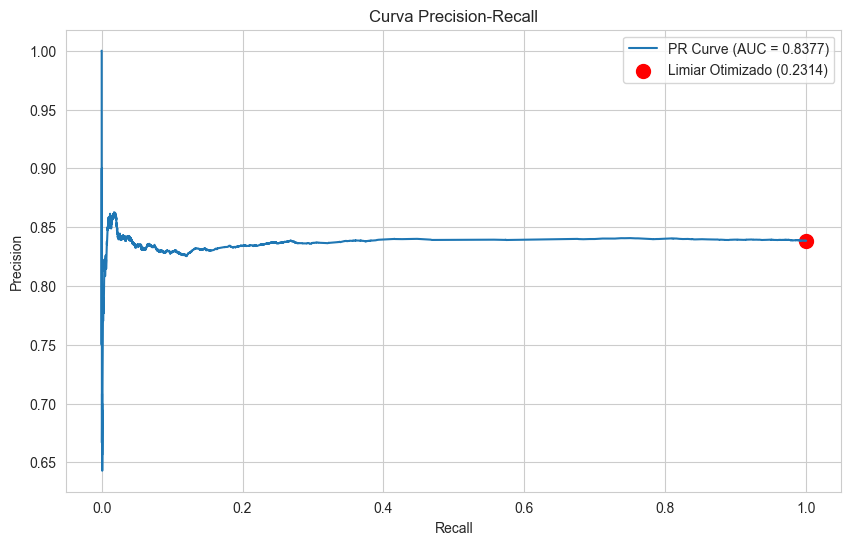

In [6]:
# Predições de probabilidade no conjunto de teste
y_proba = final_model.predict_proba(X_test_proc)[:, 1]

# Otimizar limiar de decisão usando curva precision-recall
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

# Calcular F1-score para cada limiar
f1_scores = 2 * (precision * recall) / (precision + recall)
# Remover valores NaN
f1_scores = np.nan_to_num(f1_scores)

# Encontrar limiar que maximiza F1-score
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]

print(f"Limiar otimizado: {optimal_threshold:.4f}")
print(f"F1-score otimizado: {optimal_f1:.4f}")

# Aplicar limiar otimizado para previsões finais
y_pred_optimized = (y_proba >= optimal_threshold).astype(int)

# Avaliação final
print("\n" + "="*50)
print("AVALIAÇÃO FINAL DO MODELO")
print("="*50)

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_optimized))

print(f"\nROC AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_optimized)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benigno', 'Malicioso'])

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão - Modelo Final')
plt.show()

# Curva Precision-Recall
plt.figure(figsize=(10, 6))
pr_auc = auc(recall, precision)
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.4f})')
plt.scatter(recall[optimal_idx], precision[optimal_idx], color='red', s=100, 
           label=f'Limiar Otimizado ({optimal_threshold:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend()
plt.grid(True)
plt.show()